<a href="https://colab.research.google.com/github/sheicksen/CISC483-EngageTactics/blob/JiaQi-RNN-Implementation/Truthseeker_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Attempted RNN Implementation

- RNN useful when the order of sentence matter
- RNN has use in sentiment classification (words that go with certain emotions), want to extend this to fake news
- Want to be able to predict real/fake news, associating certain words with fake news

### Step 1: Imports

In [1]:
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import files

### Step 2: Upload Truthseeker file and Print Information about File

In [11]:
# Assuming you upload a file named 'your_file_name.csv'
uploaded = files.upload()

# Get the name of the uploaded file(s)
# This assumes only one file is uploaded. If multiple, you'll need to choose the correct one.
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')
  truthseeker_df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

# Display the first few rows of the DataFrame, shape and headers, and some general info
display(truthseeker_df.head())
print(truthseeker_df.shape)
print(truthseeker_df.info())

# View the distribution of answers in the '3_label_majority_answer' column, wanted to check for null values
display(truthseeker_df['3_label_majority_answer'].value_counts())

,Unnamed: 0,author,statement,target,BinaryNumTarget,manual_keywords,tweet,5_label_majority_answer,3_label_majority_answer
0,0,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@POTUS Biden Blunders - 6 Month Update\n\nInfl...,Mostly Agree,Agree
1,1,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@S0SickRick @Stairmaster_ @6d6f636869 Not as m...,NO MAJORITY,Agree
2,2,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",THE SUPREME COURT is siding with super rich pr...,Agree,Agree
3,3,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@POTUS Biden Blunders\n\nBroken campaign promi...,Mostly Agree,Agree
4,4,D.L. Davis,End of eviction moratorium means millions of A...,True,1.0,"Americans, eviction moratorium",@OhComfy I agree. The confluence of events rig...,Agree,Agree


(134198, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134198 entries, 0 to 134197
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               134198 non-null  int64  
 1   author                   134198 non-null  object 
 2   statement                134198 non-null  object 
 3   target                   134198 non-null  bool   
 4   BinaryNumTarget          134198 non-null  float64
 5   manual_keywords          134198 non-null  object 
 6   tweet                    134198 non-null  object 
 7   5_label_majority_answer  134198 non-null  object 
 8   3_label_majority_answer  134198 non-null  object 
dtypes: bool(1), float64(1), int64(1), object(6)
memory usage: 8.3+ MB
None


,count
3_label_majority_answer,
Agree,128471
Disagree,5727


### Step 3: Remove Mentions, Establish Truth Value of Tweets, Sample Total Data, and Break Up into Train & Test Sets

In [7]:
import re # Import regular expression module

# Define target (y) and features (X)

# X is the input, want to train the model on the tweets
X = truthseeker_df['tweet']

# Function to remove mentions
def remove_mentions(text):
    return re.sub(r'@\S+', '', text)

# Apply the function to X to clean mentions
X_cleaned = X.apply(remove_mentions)
print("Cleaned entry:", X_cleaned[1])

# Determining the truth value of Truthseeker tweets is not straightforward, need to combine truth value of the news statement with whether the tweets
  # agrees with the statement
# Define the new target 'y' by XORing '3_label_majority_answer' (converted to binary) with 'BinaryNumTarget'
# We'll assume 'Agree' from '3_label_majority_answer' means 0 and disagree means 1
y_3_label_binary = (truthseeker_df['3_label_majority_answer'] != 'Agree').astype(int)

# Perform the XOR operation. Ensure both are integers for bitwise XOR.
# In y, 1 = true tweet and 0 = fake tweet
y = (y_3_label_binary ^ truthseeker_df['BinaryNumTarget'].astype(int))
print("Distribution of y:") # printing distribution of 1s and 0s in y
print(y.value_counts())

# at 0.01, with high epoch, saw clear overfitting
sample_fraction = 0.25 # Adjust this value to change the sample size

# Sample the data before splitting
X_sample, y_sample = X_cleaned.sample(frac=sample_fraction, random_state=42), y.sample(frac=sample_fraction, random_state=42)

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample)

print("Distribution of y_train:")
print(y_train.value_counts()) # distribution of 1s and 0s in training set
print("Distribution of y_test:")
print(y_test.value_counts()) # distribution of 1s and 0s in testing set

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Cleaned entry:    Not as many people are literally starving and out in the streets as they were in the 19th century. Isnt capitalism grand?

Meanwhile, were facing an eviction moratorium threatening to make millions of Americans homeless.

Fuck off with this corporatist propaganda.
Distribution of y:
1    68985
0    65213
Name: count, dtype: int64
Distribution of y_train:
1    13869
0    12971
Name: count, dtype: int64
Distribution of y_test:
1    3467
0    3243
Name: count, dtype: int64
X_train shape: (26840,)
X_test shape: (6710,)
y_train shape: (26840,)
y_test shape: (6710,)


### Step 4: Establish Tokenizer

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Calculate the length of each tweet
tweet_lengths = truthseeker_df['tweet'].apply(len)

# Print some stats on length
print(f"Mean tweet length: {tweet_lengths.mean():.2f}")
print(f"Max tweet length: {tweet_lengths.max()}")
print(f"Median tweet length: {tweet_lengths.median()}")
print(f"Min tweet length: {tweet_lengths.min()}")

# Parameters for tokenization (turn words into an ID number) and padding
VOCAB_SIZE = 10000  # Max number of words to keep track of, based on word frequency
MAX_SEQUENCE_LENGTH = 150 # Max length of each tweet sequence, will pad or shorten to this length

# Initialize tokenizer, OOV = "out of vocabulary"
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")

# Fit tokenizer on the cleaned text
tokenizer.fit_on_texts(X_cleaned)

# Convert text to sequences of numbers using the fitted tokenizer
training_sequences = tokenizer.texts_to_sequences(X_train)
testing_sequences = tokenizer.texts_to_sequences(X_test)

# Pad sequences to ensure uniform length
padded_training_sequences = pad_sequences(training_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
padded_testing_sequences = pad_sequences(testing_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"Shape of padded training sequences: {padded_training_sequences.shape}")
print(f"Shape of padded testing sequences: {padded_testing_sequences.shape}")
# each number is an ID for that word, assigned by tokenizer
print(f"Example of a padded sequence:\n{padded_training_sequences[1]}")
print(f"Vocabulary size: {len(tokenizer.word_index)}") # many of these words are out of vocabulary

Shape of padded training sequences: (26840, 150)
Shape of padded testing sequences: (6710, 150)
Example of a padded sequence:
[   2  344   70  422    8  113    7  300  619    7    2 3013  802    8
   64 2184  274   27   97    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0]
Vocabulary size: 66620


#### Step 4a: Save Tokenizer File to Colab Files

In [ ]:
import json

# Save the tokenizer configuration to a JSON file, called tokenizer.json
tokenizer_json = tokenizer.to_json()
with open('tokenizer.json', 'w', encoding='utf-8') as f:
    f.write(json.dumps(tokenizer_json, ensure_ascii=False))

print("Tokenizer saved to tokenizer.json")

Tokenizer saved to tokenizer.json


This `tokenizer.json` file can later be loaded to reconstruct the exact same tokenizer, which is crucial for using the trained model with new, unseen text data consistently.

### Step 5: Incorporating Pre-trained Word Embeddings (word2vec)

Embeddings are a vector which represents a word's meaning and the context in which it is used. Because these take a long time to train, they will be imported from word2vec.

In this step, you can either upload the embedding file (if you already have it), or else it will go and download it (then saving it)

In [14]:
%pip install gensim
import gensim.models
import gensim.downloader as api
import os

model_path = 'word2vec-google-news-300.bin'

try: # tries to load the file in, if it has been uploaded beforehand
    loaded_word2vec_model = gensim.models.KeyedVectors.load(model_path)
    print("Word2Vec model loaded from saved file.")
except Exception as e:
    # If loading fails, it might be due to a corrupted or incomplete file.
    # Attempt to re-download the model.
    print(f"Error loading saved Word2Vec model: {e}. Attempting to re-download.")
    print("Downloading Word2Vec model. This may take a while...")
    word2vec_model = api.load("word2vec-google-news-300")
    print("Word2Vec model re-downloaded.")

    # Save the re-downloaded model for future use
    word2vec_model.save(model_path)
    print(f"Word2Vec model re-saved to {model_path}")

    loaded_word2vec_model = word2vec_model # Assign the re-downloaded model

embeddings_index = loaded_word2vec_model # for compatibility with existing code

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 19.5 MB/s eta 0:00:00
Error loading saved Word2Vec model: [Errno 2] No such file or directory: 'word2vec-google-news-300.bin'. Attempting to re-download.
[=-------------------------------------------------] 3.2% 53.8/1662.8MB downloaded

KeyboardInterrupt: 

### Step 6: Creating Embedding Matrix, using Saved Embeddings.
Will adjust the embedding matrix to fit the current vocabulary

In [ ]:
# Create an embedding matrix
EMBEDDING_DIM = 300 # Word2Vec Google News vectors are 300-dimensional

# Setting up the matrix. If a word is in the saved embeddings, pull that vector. Otherwise, it will be a blank vector of 0s
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))
for word, i in tokenizer.word_index.items():
    if i < VOCAB_SIZE: # make sure to only look at tokenizer words within vocabulary
        # Check if the word exists in the Word2Vec model's vocabulary
        if word in embeddings_index:
            embedding_vector = embeddings_index[word] # Access vector directly
            embedding_matrix[i] = embedding_vector

print(f'Shape of embedding matrix: {embedding_matrix.shape}')
print(embedding_matrix)

# Print the amount of zero rows in matrix, which the amount of words not found in the imported embeddings
zero_rows = np.all(embedding_matrix == 0, axis=1)
num_zero_rows = np.sum(zero_rows)

print(f"Number of rows with all zeros in the embedding matrix: {num_zero_rows}")
print(f"This means {num_zero_rows} words from your vocabulary did not have a pre-trained embedding in the Word2Vec model and were initialized to zeros.")

Shape of embedding matrix: (10000, 300)
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.08007812  0.10498047  0.04980469 ...  0.00366211  0.04760742
  -0.06884766]
 ...
 [-0.02441406  0.0625     -0.07763672 ...  0.21582031 -0.22949219
   0.04101562]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]


### Step 7: Training Model (Bidirectional LSTM) with the Pre-Trained Embeddings
LSTM: Version of RNN which can hold important information for longer
Bidirectional: LSTM reads text from both ends (front to back, back to front), giving it additional context

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Define the LSTM model with pre-trained embeddings, bidirectional so it analyzes tweet from both directions
model_pretrained_embedding = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, weights=[embedding_matrix], trainable=True), #trainable so that embeddings can still be tweaked during training
    Bidirectional(LSTM(units=64)),
    Dense(64, activation='relu'), # relu layer to better capture patterns
    Dense(1, activation='sigmoid') # condense answer to a 1 or 0
])

# Compile the model, adjusting how fast it learns through optimizer
optimizer = Adam(learning_rate=0.01)
model_pretrained_embedding.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', 'f1_score'])

# Print model summary
model_pretrained_embedding.summary()

# Define EarlyStopping callback
# It monitors 'val_loss' and stops if it doesn't improve for 3 consecutive epochs.
# 'restore_best_weights' ensures the model keeps the weights from the epoch with the best validation loss.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train the model with early stopping
history_pretrained = model_pretrained_embedding.fit(
    padded_training_sequences, # Input Data
    y_train, # The label (answer)
    epochs=5, # Start with a reasonable number of epochs
    batch_size=32,
    validation_split=0.2, # 20% of training data set to validation
    callbacks=[early_stopping]
)

print("Model training with pre-trained embeddings complete.")

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 3,000,000 (11.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
671/671 ━━━━━━━━━━━━━━━━━━━━ 275s 403ms/step - accuracy: 0.8826 - f1_score: 0.6802 - loss: 0.3189 - val_accuracy: 0.9041 - val_f1_score: 0.6859 - val_loss: 0.2946
Epoch 2/5
671/671 ━━━━━━━━━━━━━━━━━━━━ 281s 418ms/step - accuracy: 0.9358 - f1_score: 0.6802 - loss: 0.2140 - val_accuracy: 0.9048 - val_f1_score: 0.6859 - val_loss: 0.3020
Epoch 3/5
671/671 ━━━━━━━━━━━━━━━━━━━━ 309s 399ms/step - accuracy: 0.9423 - f1_score: 0.6802 - loss: 0.1888 - val_accuracy: 0.9013 - val_f1_score: 0.6859 - val_loss: 0.2993
Epoch 4/5
671/671 ━━━━━━━━━━━━━━━━━━━━ 327s 407ms/step - accuracy: 0.9479 - f1_score: 0.6802 - loss: 0.1682 - val_accuracy: 0.8949 - val_f1_score: 0.6859 - val_loss: 0.3416
Epoch 5/5
671/671 ━━━━━━━━━━━━━━━━━━━━ 271s 404ms/step - accuracy: 0.9485 - f1_score: 0.6802 - loss: 0.1645 - val_accuracy: 0.8951 - val_f1_score: 0.6859 - val_loss: 0.3411
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
Model training with pre-trained embeddings complete.

### Step 8: Evaluating Model Performance
- Apply model on testing set
- Crerate confusion matrix visualizing the results

In [ ]:
# Evaluate the model with pre-trained embeddings on the test data, prints loss, accuracy, and f1_score
loss_pretrained, accuracy_pretrained, f1_score_pretrained = model_pretrained_embedding.evaluate(padded_testing_sequences, y_test)

print(f"\nTest Loss (Pre-trained Embeddings): {loss_pretrained:.4f}")
print(f"Test Accuracy (Pre-trained Embeddings): {accuracy_pretrained:.4f}")
print(f"Test f1 (Pre-trained Embeddings): {f1_score_pretrained:.4f}")

210/210 ━━━━━━━━━━━━━━━━━━━━ 25s 118ms/step - accuracy: 0.9112 - f1_score: 0.6813 - loss: 0.2852

Test Loss (Pre-trained Embeddings): 0.2852
Test Accuracy (Pre-trained Embeddings): 0.9112
Test f1 (Pre-trained Embeddings): 0.6813


210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step


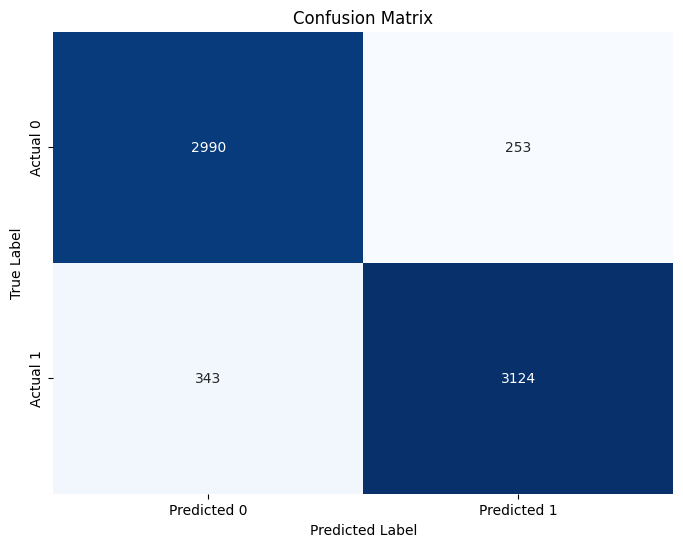

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions on the test data
y_pred_probs = model_pretrained_embedding.predict(padded_testing_sequences)

# Convert probabilities to binary integers (0 or 1)
y_pred_binary = (y_pred_probs > 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix helps us understand the types of errors made by the model:

*   **True Negatives (Top-Left)**: Correctly predicted 0 (negative class).
*   **False Positives (Top-Right)**: Incorrectly predicted 1 (positive class) when the actual was 0.
*   **False Negatives (Bottom-Left)**: Incorrectly predicted 0 (negative class) when the actual was 1.
*   **True Positives (Bottom-Right)**: Correctly predicted 1 (positive class).

By examining these values, you can gain insight into the specific strengths and weaknesses of your model's classification performance.

### Step 9: Saving the Trained Model to Colab Files

In [ ]:
model_pretrained_embedding.save('pretrained_embedding_model.keras')
print("Model saved to pretrained_embedding_model.keras")

Model saved to pretrained_embedding_model.keras
